In [2]:
# === Cell 1: imports + load ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

DATA_CACHE   = Path('data') / 'features'

df = pd.read_parquet(DATA_CACHE / 'cereal_features.parquet')
print(f'Loaded: {df.shape}')
print(f'Date range: {df["WEEK_END_DATE"].min().date()} → {df["WEEK_END_DATE"].max().date()}')

Loaded: (169676, 40)
Date range: 2009-01-14 → 2012-01-04


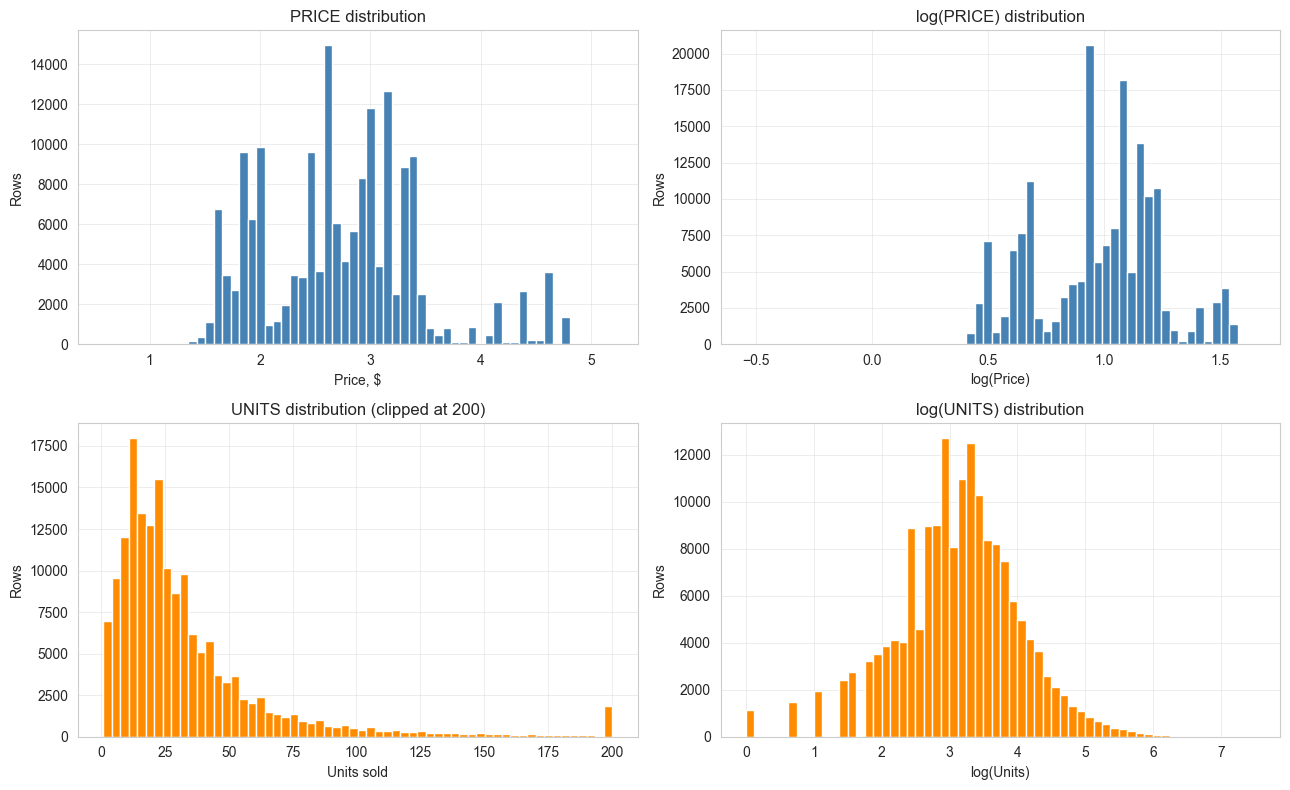


PRICE  | mean: 2.74, median: 2.72, std: 0.71
UNITS  | mean: 34.3, median: 24, std: 41.4


In [3]:
# === Cell 2: распределения цены и продаж ===
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Сырая цена
axes[0, 0].hist(df['PRICE'], bins=60, edgecolor='white', color='steelblue')
axes[0, 0].set_title('PRICE distribution')
axes[0, 0].set_xlabel('Price, $'); axes[0, 0].set_ylabel('Rows')

# Логарифм цены
axes[0, 1].hist(df['log_price'], bins=60, edgecolor='white', color='steelblue')
axes[0, 1].set_title('log(PRICE) distribution')
axes[0, 1].set_xlabel('log(Price)'); axes[0, 1].set_ylabel('Rows')

# Сырые продажи (с лимитом — длинный хвост)
axes[1, 0].hist(df['UNITS'].clip(upper=200), bins=60, edgecolor='white', color='darkorange')
axes[1, 0].set_title('UNITS distribution (clipped at 200)')
axes[1, 0].set_xlabel('Units sold'); axes[1, 0].set_ylabel('Rows')

# Логарифм продаж
axes[1, 1].hist(df['log_units'], bins=60, edgecolor='white', color='darkorange')
axes[1, 1].set_title('log(UNITS) distribution')
axes[1, 1].set_xlabel('log(Units)'); axes[1, 1].set_ylabel('Rows')

plt.tight_layout()
plt.show()

print('\nPRICE  | mean: {:.2f}, median: {:.2f}, std: {:.2f}'.format(
    df['PRICE'].mean(), df['PRICE'].median(), df['PRICE'].std()))
print('UNITS  | mean: {:.1f}, median: {:.0f}, std: {:.1f}'.format(
    df['UNITS'].mean(), df['UNITS'].median(), df['UNITS'].std()))

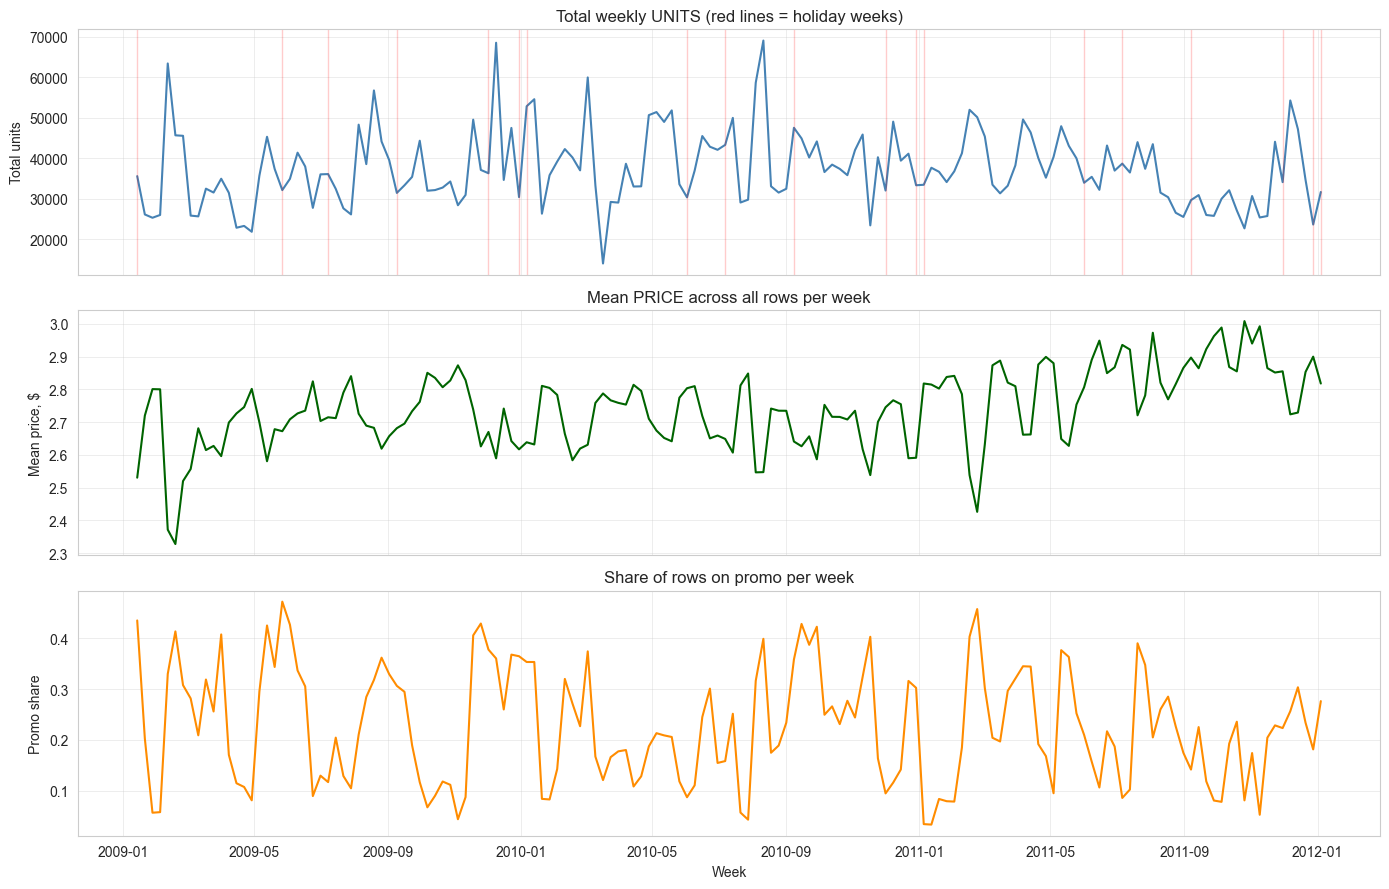


Weekly correlation (mean_price × mean_units): -0.550
Weekly correlation (promo_share × total_units): +0.507


In [4]:
# === Cell 3: временные паттерны ===

# Агрегируем продажи по неделям — суммарно и в среднем
weekly = df.groupby('WEEK_END_DATE').agg(
    total_units=('UNITS', 'sum'),
    mean_units =('UNITS', 'mean'),
    mean_price =('PRICE', 'mean'),
    promo_share=('on_promo', 'mean'),
    holiday    =('is_holiday_week', 'max'),
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 1) Суммарные продажи по неделям
axes[0].plot(weekly['WEEK_END_DATE'], weekly['total_units'], color='steelblue')

# Подсветим праздничные недели
for _, row in weekly[weekly['holiday'] == 1].iterrows():
    axes[0].axvline(row['WEEK_END_DATE'], color='red', alpha=0.2, linewidth=1)
axes[0].set_title('Total weekly UNITS (red lines = holiday weeks)')
axes[0].set_ylabel('Total units')

# 2) Средняя цена по неделям
axes[1].plot(weekly['WEEK_END_DATE'], weekly['mean_price'], color='darkgreen')
axes[1].set_title('Mean PRICE across all rows per week')
axes[1].set_ylabel('Mean price, $')

# 3) Доля промо-строк по неделям
axes[2].plot(weekly['WEEK_END_DATE'], weekly['promo_share'], color='darkorange')
axes[2].set_title('Share of rows on promo per week')
axes[2].set_ylabel('Promo share')
axes[2].set_xlabel('Week')

plt.tight_layout()
plt.show()

# Корреляция средняя цена × средние продажи на агрегате
corr = weekly[['mean_price', 'mean_units']].corr().iloc[0, 1]
print(f'\nWeekly correlation (mean_price × mean_units): {corr:+.3f}')
print(f'Weekly correlation (promo_share × total_units): {weekly[["promo_share","total_units"]].corr().iloc[0,1]:+.3f}')

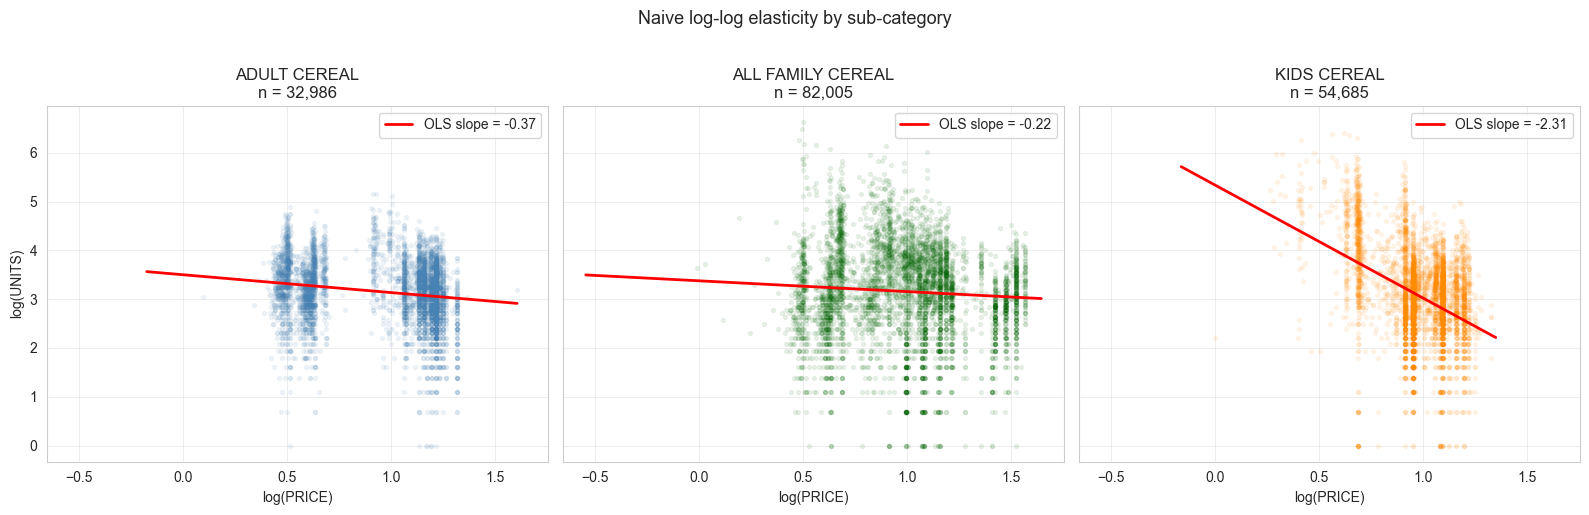


=== Naive elasticities (OLS log-log, no controls) ===
            ADULT CEREAL: -0.365
       ALL FAMILY CEREAL: -0.221
             KIDS CEREAL: -2.314
                 OVERALL: -0.521

  R² overall: 0.023


In [6]:
import statsmodels.api as sm

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
subcats = ['ADULT CEREAL', 'ALL FAMILY CEREAL', 'KIDS CEREAL']
colors  = ['steelblue', 'darkgreen', 'darkorange']

elasticities = {}

for ax, sub, color in zip(axes, subcats, colors):
    sub_df = df[df['SUB_CATEGORY'] == sub]

    sample = sub_df.sample(min(5000, len(sub_df)), random_state=42)
    ax.scatter(sample['log_price'], sample['log_units'],
               alpha=0.08, s=8, color=color)

    X = sm.add_constant(sub_df['log_price'])
    y = sub_df['log_units']
    model = sm.OLS(y, X).fit()
    elasticity = model.params['log_price']
    elasticities[sub] = elasticity

    x_line = np.linspace(sub_df['log_price'].min(), sub_df['log_price'].max(), 100)
    y_line = model.params['const'] + elasticity * x_line
    ax.plot(x_line, y_line, color='red', linewidth=2,
            label=f'OLS slope = {elasticity:.2f}')

    ax.set_title(f'{sub}\nn = {len(sub_df):,}')
    ax.set_xlabel('log(PRICE)')
    ax.legend(loc='upper right')

axes[0].set_ylabel('log(UNITS)')
plt.suptitle('Naive log-log elasticity by sub-category', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print('\n=== Naive elasticities (OLS log-log, no controls) ===')
for sub, e in elasticities.items():
    print(f'  {sub:>22}: {e:+.3f}')

# Сделаем то же на всём датасете для сравнения
X_all = sm.add_constant(df['log_price'])
model_all = sm.OLS(df['log_units'], X_all).fit()
print(f'  {"OVERALL":>22}: {model_all.params["log_price"]:+.3f}')
print(f'\n  R² overall: {model_all.rsquared:.3f}')

Naive elasticity per SKU (within-SKU only):
        UPC               DESCRIPTION      SUB_CATEGORY  MANUFACTURER  elasticity       r2     n
 3800039118          KELL FROOT LOOPS       KIDS CEREAL       KELLOGG   -4.404744 0.531273 11947
 3000006610         QKER CAP N CRUNCH       KIDS CEREAL        QUAKER   -3.741757 0.287359 10493
 3000006560 QKER CAP N CRUNCH BERRIES       KIDS CEREAL        QUAKER   -3.202223 0.264857 10173
 3800031838       KELL FROSTED FLAKES       KIDS CEREAL       KELLOGG   -2.989102 0.302528 11979
88491212971       POST FRUITY PEBBLES       KIDS CEREAL    POST FOODS   -2.892282 0.284358 10093
 3000006340        QKER LIFE ORIGINAL ALL FAMILY CEREAL        QUAKER   -2.724508 0.244386 10231
88491201427 POST FM SZ HNYBNCH OT ALM      ADULT CEREAL    POST FOODS   -2.525415 0.117227 10306
 1600027527     GM HONEY NUT CHEERIOS ALL FAMILY CEREAL    GENERAL MI   -2.512856 0.248419 11985
 1600027528               GM CHEERIOS ALL FAMILY CEREAL    GENERAL MI   -2.122150 0

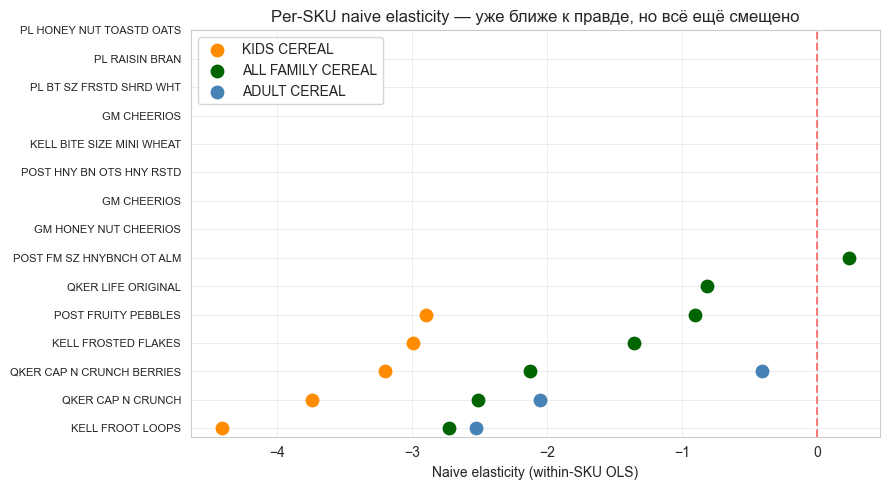

In [7]:
# === Cell 5: эластичность отдельно для каждого SKU ===
import statsmodels.api as sm

per_upc = []
for upc, sub_df in df.groupby('UPC'):
    if len(sub_df) < 100:  # пропустим редкие SKU
        continue
    X = sm.add_constant(sub_df['log_price'])
    model = sm.OLS(sub_df['log_units'], X).fit()
    per_upc.append({
        'UPC': upc,
        'DESCRIPTION': sub_df['DESCRIPTION'].iloc[0],
        'SUB_CATEGORY': sub_df['SUB_CATEGORY'].iloc[0],
        'MANUFACTURER': sub_df['MANUFACTURER'].iloc[0],
        'elasticity': model.params['log_price'],
        'r2': model.rsquared,
        'n': len(sub_df),
    })

per_upc_df = pd.DataFrame(per_upc).sort_values('elasticity')
print('Naive elasticity per SKU (within-SKU only):')
print(per_upc_df.to_string(index=False))

print(f'\nMean elasticity across SKUs : {per_upc_df["elasticity"].mean():+.2f}')
print(f'Median elasticity            : {per_upc_df["elasticity"].median():+.2f}')
print(f'Mean R² across SKUs          : {per_upc_df["r2"].mean():.3f}')

# Визуализация распределения
fig, ax = plt.subplots(figsize=(9, 5))
colors_map = {'ADULT CEREAL': 'steelblue', 'ALL FAMILY CEREAL': 'darkgreen', 'KIDS CEREAL': 'darkorange'}
for sub in per_upc_df['SUB_CATEGORY'].unique():
    subset = per_upc_df[per_upc_df['SUB_CATEGORY'] == sub]
    ax.scatter(subset['elasticity'], range(len(subset.index)),
               s=80, label=sub, color=colors_map.get(sub, 'gray'))

ax.set_yticks(range(len(per_upc_df)))
ax.set_yticklabels(per_upc_df['DESCRIPTION'], fontsize=8)
ax.axvline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Naive elasticity (within-SKU OLS)')
ax.set_title('Per-SKU naive elasticity — уже ближе к правде, но всё ещё смещено')
ax.legend()
plt.tight_layout()
plt.show()

Паттерн 1: Брендовые SKU дают −3 до −4.5. KELL FROOT LOOPS (−4.4), QKER CAP N CRUNCH (−3.7), всё семейство Kellogg's и Quaker. Это слишком много для реальной эластичности. Литература даёт −2 до −3, а у нас флагманы брендов показывают −4. Что не так?
Когда Froot Loops "пилят" цену с $3.50 до $2.50, одновременно идёт реклама в листовке (FEATURE), специальная выкладка (DISPLAY), купоны. Регрессия видит: цена ↓, спрос ↑↑↑. Но львиная доля прироста — это не цена, это рекламная активность, которая всегда идёт пакетом с глубокой скидкой. Эластичность пакета = −4. Эластичность чистой цены без рекламы — скорее −2.